In [1]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np

In [2]:
X,y = load_diabetes(return_X_y=True)

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

In [5]:
from sklearn.linear_model import SGDRegressor

In [6]:
reg = SGDRegressor(penalty='l2',max_iter=500,eta0=0.1,learning_rate='constant',alpha=0.001)

In [7]:

reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.449011603153024
[  52.45883767 -137.76928009  355.82294356  257.39990884    3.3863026
  -48.22361813 -167.4145498   140.1687606   318.37749389  103.29278349]
[162.32400763]


In [8]:

from sklearn.linear_model import Ridge

reg = Ridge(alpha=0.001, max_iter=500,solver='sparse_cg')

In [9]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.4625010162198291
[  34.52193945 -290.8408285   482.40183324  368.0678848  -852.44871025
  501.59162478  180.11113912  270.76336756  759.73536943   37.49137471]
151.10198522317984


In [10]:
class MeraRidgeGD:
    
    def __init__(self,epochs,learning_rate,alpha):
        
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,X_train,y_train):
        
        self.coef_ = np.ones(X_train.shape[1])
        self.intercept_ = 0
        thetha = np.insert(self.coef_,0,self.intercept_)
        
        X_train = np.insert(X_train,0,1,axis=1)
        
        for i in range(self.epochs):
            thetha_der = np.dot(X_train.T,X_train).dot(thetha) - np.dot(X_train.T,y_train) + self.alpha*thetha
            thetha = thetha - self.learning_rate*thetha_der
        
        self.coef_ = thetha[1:]
        self.intercept_ = thetha[0]
    
    def predict(self,X_test):
        
        return np.dot(X_test,self.coef_) + self.intercept_

In [36]:
reg = MeraRidgeGD(epochs=500,alpha=0.01,learning_rate=0.005)

In [37]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.473504930712384
[  46.7793791  -219.09300433  449.40170514  323.72132129  -28.24350919
  -95.16971513 -190.21178936  146.11378967  398.50851788   95.34728499]
150.8727331471031


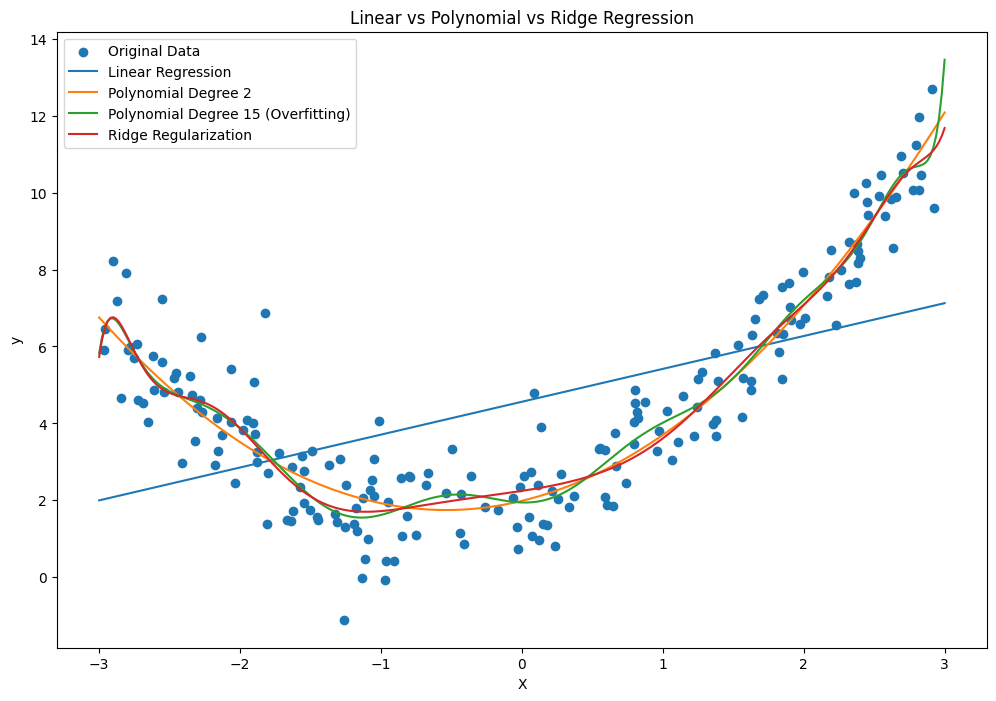

In [38]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# -----------------------------
# DATASET
# -----------------------------
np.random.seed(42)

X = 6 * np.random.rand(200,1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200,1)

# smooth values for plotting curve
X_new = np.linspace(-3,3,300).reshape(300,1)

# -----------------------------
# MODELS
# -----------------------------

# 1. Simple Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X,y)

y_lin = lin_reg.predict(X_new)

# 2. Polynomial Regression (degree 2)
poly2_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("lr", LinearRegression())
])

poly2_model.fit(X,y)

y_poly2 = poly2_model.predict(X_new)

# 3. High Degree Polynomial (Overfitting)
poly15_model = Pipeline([
    ("poly", PolynomialFeatures(degree=15, include_bias=False)),
    ("lr", LinearRegression())
])

poly15_model.fit(X,y)

y_poly15 = poly15_model.predict(X_new)

# 4. Polynomial + Ridge Regularization
ridge_model = Pipeline([
    ("poly", PolynomialFeatures(degree=15, include_bias=False)),
    ("ridge", Ridge(alpha=10))
])

ridge_model.fit(X,y)

y_ridge = ridge_model.predict(X_new)

# -----------------------------
# PLOTTING
# -----------------------------

plt.figure(figsize=(12,8))

# original data
plt.scatter(X,y,label="Original Data")

# linear regression
plt.plot(X_new,y_lin,label="Linear Regression")

# polynomial degree 2
plt.plot(X_new,y_poly2,label="Polynomial Degree 2")

# overfitting curve
plt.plot(X_new,y_poly15,label="Polynomial Degree 15 (Overfitting)")

# ridge regularization
plt.plot(X_new,y_ridge,label="Ridge Regularization")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear vs Polynomial vs Ridge Regression")

plt.legend()
plt.show()